## Data Sourcing

**Concept:** Fetching and Saving the California Housing Dataset

In [2]:
import os
import certifi
import pandas as pd
from sklearn.datasets import fetch_california_housing

# Use the certifi certificate bundle for HTTPS connections
os.environ["SSL_CERT_FILE"] = certifi.where()

# 1. Fetch the dataset with dataframe format enabled from scikit-learn
california = fetch_california_housing(as_frame=True)
df_california = california.frame

# 2. Ensure the raw data directory exists
os.makedirs('../data/raw', exist_ok=True)

# 3. Save the dataframe to a CSV file
df_california.to_csv('../data/raw/california_housing.csv', index=False)

print("Dataset successfully saved to data/raw/california_housing.csv!")
print("Shape of dataset:", df_california.shape)

Dataset successfully saved to data/raw/california_housing.csv!
Shape of dataset: (20640, 9)


## Data Sourcing via Web API

**Concept:** *Fetching Live Data Using Python*

**An API (Application Programming Interface)** acts as a bridge that allows your Python script to talk to a remote server and download live data over the internet. For this assignment, we can connect to the Open Data Toronto portal to fetch real estate or housing-related datasets.

In [5]:
import requests

# Toronto Open Data CKAN API package search endpoint
url = "https://ckan0.cf.opendata.utoronto.ca/api/3/action/package_search"
params = {"q": "housing", "rows": 5}

try:
    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()

    data = response.json()

    if data.get("success"):
        print("API Connection Successful!")

        results = data["result"]["results"]
        print(f"Found {len(results)} datasets related to housing.")
    else:
        print("The API returned an unsuccessful response.")

except requests.exceptions.RequestException as error:
    print(f"Failed to fetch data: {error}")

Failed to fetch data: HTTPSConnectionPool(host='ckan0.cf.opendata.utoronto.ca', port=443): Max retries exceeded with url: /api/3/action/package_search?q=housing&rows=5 (Caused by NameResolutionError("HTTPSConnection(host='ckan0.cf.opendata.utoronto.ca', port=443): Failed to resolve 'ckan0.cf.opendata.utoronto.ca' ([Errno 11001] getaddrinfo failed)"))


## Relational Database (SQLite) & Basic EDA

**Concept:** *Connecting to a Relational Database*
**Relational databases** store data structured in tables containing rows and columns. For your project deliverable, we can create a lightweight, portable local database using SQLite with the help of sqlalchemy, run a SQL query to filter or select records, and load the results directly into a Pandas DataFrame for your Exploratory Data Analysis (EDA).

Successfully loaded 1000 rows from the SQLite database!


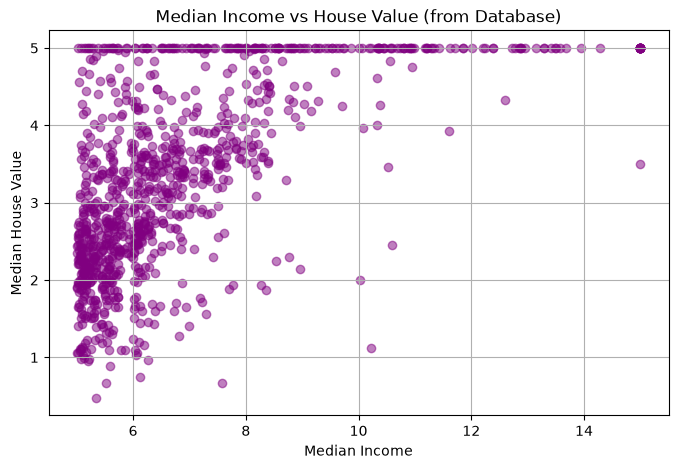

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from sqlalchemy import create_engine

# 1. Create a lightweight local SQLite database connection
# (This creates a file named housing.db locally in your project folder)
engine = create_engine('sqlite:///housing.db')

# 2. Save our California housing dataframe into a SQL table for demonstration
# (Assuming 'df_california' is already loaded from our previous step)
df_california.to_sql(
    'housing_prices', con=engine, if_exists='replace', index=False
)

# 3. Query data back from the database using SQL
query = 'SELECT * FROM housing_prices WHERE MedInc > 5.0 LIMIT 1000'
df_from_db = pd.read_sql(query, con=engine)

print(f'Successfully loaded {len(df_from_db)} rows from the SQLite database!')

# 4. Basic EDA: Plotting Median Income vs. House Value
plt.figure(figsize=(8, 5))
plt.scatter(
    df_from_db['MedInc'],
    df_from_db['MedHouseVal'],
    alpha=0.5,
    color='purple',
)
plt.title('Median Income vs House Value (from Database)')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.grid(True)
plt.show()